In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
user = pd.read_csv('/content/sample_data/user.csv')
activity = pd.read_csv('/content/sample_data/activity.csv')
message = pd.read_csv('/content/sample_data/message.csv')
video = pd.read_csv('/content/sample_data/video.csv')
post = pd.read_csv('/content/sample_data/post.csv')

# Анализ данных

## Задание 1

In [3]:
# Сколько всего пользователей?
total_users = user['user_id'].nunique()
print(f"Всего пользователей: {total_users}")

1. Всего пользователей: 1000


In [4]:
# Какого типа активностей больше всего?
activity_type_counts = activity['activity_type'].value_counts()
most_common = activity_type_counts.idxmax()
print(f"Больше всего активностей типа: {most_common} ({activity_type_counts[most_common]} шт.)")

2. Больше всего активностей типа: message (1585 шт.)


In [5]:
# Пользователи без активности
users_with_activity = set(activity['user_id'].unique())
all_users = set(user['user_id'].unique())
inactive_users = all_users - users_with_activity
print(f"Пользователей без активности: {len(inactive_users)}")

Пользователей без активности: 183


In [6]:
# Пользователи с активностью, но без даты рождения
active_users = user[user['user_id'].isin(users_with_activity)]
active_no_birthdate = active_users['birth_date'].isna().sum()
print(f"Пользователей с активностью, но без даты рождения: {active_no_birthdate}")

Пользователей с активностью, но без даты рождения: 159


## Задание 2

In [7]:
# За сообщения
msg_scored = message.merge(activity[['activity_id', 'user_id']], on='activity_id')

def msg_score(length):
    if length < 20:
        return 1
    elif length < 100:
        return 2
    else:
        return 3

msg_scored['score'] = msg_scored['num_characters'].apply(msg_score)
msg_scores = msg_scored.groupby('user_id')['score'].sum()

In [8]:
# За видео
video_scored = video.merge(activity[['activity_id', 'user_id']], on='activity_id')
video_scored['score'] = video_scored['view_duration_sec'] // 60
video_scores = video_scored.groupby('user_id')['score'].sum()

In [10]:
# За посты
post_scored = post.merge(activity[['activity_id', 'user_id']], on='activity_id')

def post_score(row):
    if row['interaction_type'] == 'like':
        return 1
    else:
        if pd.isna(row['num_characters']) or row['num_characters'] < 50:
            return 2
        else:
            return 4

post_scored['score'] = post_scored.apply(post_score, axis=1)
post_scores = post_scored.groupby('user_id')['score'].sum()

In [11]:
# Сумма
all_scores = pd.concat([msg_scores, video_scores, post_scores], axis=1).fillna(0)
all_scores['total_score'] = all_scores.sum(axis=1)

In [12]:
# Онли юзеры с активностью
active_users_scores = all_scores[all_scores['total_score'] > 0]

mean_score = active_users_scores['total_score'].mean()
print(f"Средний индекс активности: {mean_score:.2f}")

Средний индекс активности: 7.77


## Задание 3

In [13]:
# Определяем группы
def get_group(score):
    if score < 5:
        return 1
    elif score < 10:
        return 2
    else:
        return 3

active_users_scores['group'] = active_users_scores['total_score'].apply(get_group)

/tmp/ipykernel_6602/2164108456.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_users_scores['group'] = active_users_scores['total_score'].apply(get_group)


In [14]:
# Кол-во пользователей в группах
group_counts = active_users_scores['group'].value_counts().sort_index()
print(f"Группа 1 (активность < 5): {group_counts.get(1, 0)} пользователей")
print(f"Группа 2 (5 ≤ активность < 10): {group_counts.get(2, 0)} пользователей")
print(f"Группа 3 (активность ≥ 10): {group_counts.get(3, 0)} пользователей")

Группа 1 (активность < 5): 208 пользователей
Группа 2 (5 ≤ активность < 10): 330 пользователей
Группа 3 (активность ≥ 10): 260 пользователей


In [15]:
# Расчёт возраста на момент 1 января 2025
def calculate_age(birth_date_str):
    if pd.isna(birth_date_str):
        return np.nan
    birth = datetime.strptime(birth_date_str, '%Y-%m-%d')
    ref = datetime(2025, 1, 1)
    age = ref.year - birth.year - ((ref.month, ref.day) < (birth.month, birth.day))
    return age

user['age'] = user['birth_date'].apply(calculate_age)

In [16]:
# Объединяем
user_with_group = user[user['user_id'].isin(active_users_scores.index)].merge(
    active_users_scores[['total_score', 'group']],
    left_on='user_id',
    right_index=True
)

In [17]:
# Средний по группе
mean_ages = user_with_group.dropna(subset=['age']).groupby('group')['age'].mean().apply(np.floor).astype(int)

print(f"\nСредний возраст в группе 1: {mean_ages.get(1, 0)}")
print(f"Средний возраст в группе 2: {mean_ages.get(2, 0)}")
print(f"Средний возраст в группе 3: {mean_ages.get(3, 0)}")


Средний возраст в группе 1: 49
Средний возраст в группе 2: 47
Средний возраст в группе 3: 48


## Задание 4

In [20]:
# Восстанавливаем возраст для пропусков
user_with_group['restored_age'] = user_with_group['age']

for group in [1, 2, 3]:
    mean_age = mean_ages.get(group, 0)
    mask = (user_with_group['group'] == group) & (user_with_group['age'].isna())
    user_with_group.loc[mask, 'restored_age'] = mean_age

filtered = user_with_group[
    (user_with_group['restored_age'] >= 49) &
    (user_with_group['group'] == 1)
]

print(f"Пользователей не младше 49 лет с активностью < 5: {len(filtered)}")

Пользователей не младше 49 лет с активностью < 5: 122


# Машинное обучение

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [23]:
data = pd.read_csv('/content/sample_data/data.csv')
x = data['x'].values
y = data['y'].values

# Задание 1

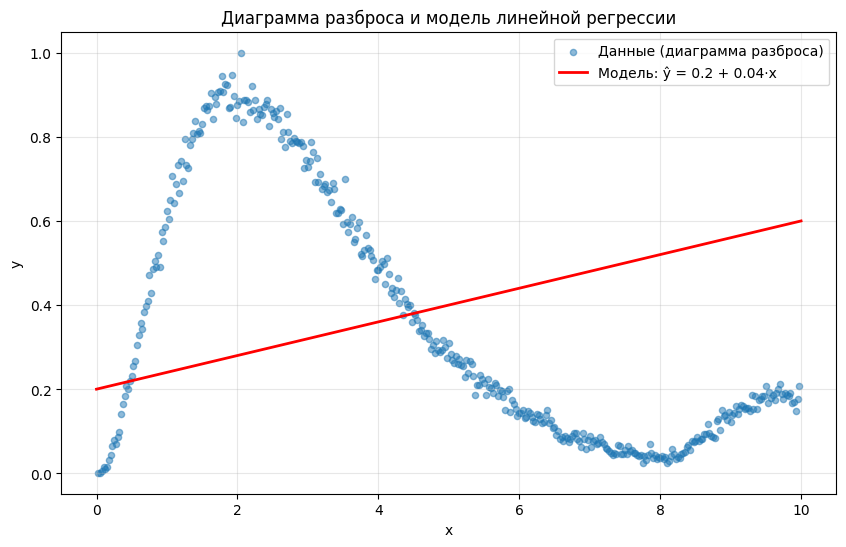

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, s=20, label='Данные (диаграмма разброса)')

x_line = np.linspace(0, 10, 100)
y_line = 0.2 + 0.04 * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Модель: ŷ = 0.2 + 0.04·x')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Диаграмма разброса и модель линейной регрессии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot.png', dpi=100)
plt.show()

## Задание 2

1. От минус бесконечности до 1
2. Когда значение R^2 большое (близкое к 1)

In [26]:
y_pred_given = 0.2 + 0.04 * x
r2_given = r2_score(y, y_pred_given)
print(f"\nR² для модели ŷ = 0.2 + 0.04·x: {r2_given:.4f}")
print(f"Округлённый ответ: {r2_given:.2f}")


R² для модели ŷ = 0.2 + 0.04·x: -0.7077
Округлённый ответ: -0.71


## Задание 3

In [29]:
model_full = LinearRegression()
model_full.fit(x.reshape(-1, 1), y)
print(f"Стандартная линейная регрессия (без ограничений):")
print(f"w0= {model_full.intercept_:.4f}")
print(f"w1= {model_full.coef_[0]:.4f}")
print(f"R^2= {model_full.score(x.reshape(-1, 1), y):.4f}")

print("\nПо условию: w0 [0.6, 0.8], w1 [-0.1, 0]")

best_r2 = -np.inf
best_w0 = None
best_w1 = None

for w0 in np.linspace(0.6, 0.8, 50):
    for w1 in np.linspace(-0.1, 0, 50):
        y_pred = w0 + w1 * x
        r2 = r2_score(y, y_pred)
        if r2 > best_r2:
            best_r2 = r2
            best_w0 = w0
            best_w1 = w1

print(f"\nОптимальные параметры в заданных диапазонах:")
print(f"w0= {best_w0:.4f}")
print(f"w1= {best_w1:.4f}")
print(f"R^2= {best_r2:.4f}")
print(f"\nОкруглённый ответ: {best_r2:.2f}")

Стандартная линейная регрессия (без ограничений):
w0= 0.7028
w1= -0.0697
R^2= 0.4629

По условию: w0 [0.6, 0.8], w1 [-0.1, 0]

Оптимальные параметры в заданных диапазонах:
w0= 0.7020
w1= -0.0694
R^2= 0.4629

Округлённый ответ: 0.46


## Задание 4

In [30]:
ranges = [(i, i+1) for i in range(10)]

h_values = []
y_pred_const = np.zeros_like(y)

for a, b in ranges:
    mask = (x >= a) & (x < b)
    if mask.any():
        h = y[mask].mean()
    else:
        h = 0
    h_values.append(h)
    y_pred_const[mask] = h

r2_const = r2_score(y, y_pred_const)
print(f"R^2 для кусочно-константной модели: {r2_const:.6f}")
print(f"Округлённый ответ: {r2_const:.3f}")

R^2 для кусочно-константной модели: 0.927657
Округлённый ответ: 0.928


## Задание 5

In [31]:
y_pred_piecewise_linear = np.zeros_like(y)

for a, b in ranges:
    mask = (x >= a) & (x < b)
    if mask.sum() >= 2:
        x_segment = x[mask].reshape(-1, 1)
        y_segment = y[mask]
        model_segment = LinearRegression()
        model_segment.fit(x_segment, y_segment)
        y_pred_piecewise_linear[mask] = model_segment.predict(x_segment)
    elif mask.sum() == 1:
        y_pred_piecewise_linear[mask] = y[mask].mean()
    else:
        pass

r2_piecewise = r2_score(y, y_pred_piecewise_linear)
print(f"R^2 для кусочно-линейной модели: {r2_piecewise:.6f}")
print(f"Округлённый ответ: {r2_piecewise:.3f}")

R^2 для кусочно-линейной модели: 0.994428
Округлённый ответ: 0.994
